In [ ]:
import os

DATA_DIR = r'C:\Users\perei\OneDrive\Documentos\ADS\modulo-03\inteligencia artificial\cifar-100-python\data'
OUTPUT_DIR = r'C:\Users\perei\OneDrive\Documentos\ADS\modulo-03\inteligencia artificial\cifar-100-python\outputs'

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Diretório não encontrado: {DATA_DIR}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

files = os.listdir(DATA_DIR)

print("Arquivos disponíveis:")
if not files:
    print("  (nenhum arquivo encontrado)")
else:
    for f in files:
        print(f"  {f}")

Arquivos disponíveis:
  meta
  test
  train


In [ ]:
import os
import pickle
import json
import numpy as np
from datetime import datetime
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import mixed_precision

# Mixed Precision — ~2x mais rápido
mixed_precision.set_global_policy('mixed_float16')

# CONFIG
CONFIG = {
    'depth':           34,
    'width':           10,
    'epochs':          180,
    'batch_size':      256,
    'initial_lr':      0.2,
    'dropout':         0.2,
    'label_smoothing': 0.1,
    'use_cosine':      False,
    'use_ema':         False,
}
USE_MIXUP  = True
USE_CUTMIX = True
WD = 1e-4

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Sem GPU — ative em Settings > Accelerator > GPU")

print(f"TensorFlow: {tf.__version__}")
print(f"Precisão: {mixed_precision.global_policy().name}")

2026-06-29 15:39:54.004307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782747594.243333      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782747594.310668      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782747594.872258      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782747594.872295      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782747594.872298      23 computation_placer.cc:177] computation placer alr

✅ GPU: /physical_device:GPU:0
TensorFlow: 2.19.0
Precisão: mixed_float16


In [3]:
def carregar_cifar100(arquivo):
    with open(arquivo, 'rb') as f:
        return pickle.load(f, encoding='bytes')

treino = carregar_cifar100(os.path.join(DATA_DIR, 'train'))
teste  = carregar_cifar100(os.path.join(DATA_DIR, 'test'))
meta   = carregar_cifar100(os.path.join(DATA_DIR, 'meta'))

X_treino = treino[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_treino = np.array(treino[b'fine_labels'])

X_teste = teste[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_teste = np.array(teste[b'fine_labels'])

nomes_classes = [c.decode('utf-8') for c in meta[b'fine_label_names']]

print(f"Treino : {X_treino.shape}")
print(f"Teste  : {X_teste.shape}")
print(f"Classes: {len(nomes_classes)}")

Treino : (50000, 32, 32, 3)
Teste  : (10000, 32, 32, 3)
Classes: 100


In [ ]:
def random_erasing(image, prob=0.5, sl=0.02, sh=0.4, r1=0.3):
    def erase(image):
        area = 32.0 * 32.0
        target_area = tf.random.uniform([], sl, sh) * area
        aspect_ratio = tf.random.uniform([], r1, 1.0 / r1)

        h = tf.cast(tf.round(tf.sqrt(target_area * aspect_ratio)), tf.int32)
        w = tf.cast(tf.round(tf.sqrt(target_area / aspect_ratio)), tf.int32)

        h = tf.clip_by_value(h, 1, 31)
        w = tf.clip_by_value(w, 1, 31)

        y = tf.random.uniform([], 0, 32 - h, dtype=tf.int32)
        x = tf.random.uniform([], 0, 32 - w, dtype=tf.int32)

        noise = tf.random.uniform([h, w, 3])
        padding = [[y, 32 - y - h], [x, 32 - x - w], [0, 0]]
        noise_padded = tf.pad(noise, padding)
        mask = tf.pad(tf.ones([h, w, 3]), padding)

        return image * (1.0 - mask) + noise_padded * mask

    return tf.cond(tf.random.uniform([]) < prob, lambda: erase(image), lambda: image)


def autoaugment_cifar(image):
    """AutoAugment simplificado para CIFAR-100."""
    def apply_op(image, op, magnitude):
        if op == 0:  # AutoContrast
            return tf.image.adjust_contrast(image, magnitude * 0.5 + 0.5)
        elif op == 1:  # Brightness
            return tf.image.adjust_brightness(image, magnitude * 0.3)
        elif op == 2:  # Sharpness (via contrast proxy)
            return tf.image.adjust_contrast(image, 1.0 + magnitude * 0.5)
        elif op == 3:  # Equalize (via saturation proxy)
            return tf.image.adjust_saturation(image, 1.0 + magnitude * 0.3)
        elif op == 4:  # Solarize (inverte pixels acima de threshold)
            threshold = 0.5 + magnitude * 0.3
            return tf.where(image < threshold, image, 1.0 - image)
        elif op == 5:  # Color
            return tf.image.adjust_saturation(image, magnitude * 0.9 + 0.1)
        elif op == 6:  # Posterize (reduz bits)
            factor = tf.cast(tf.round(magnitude * 4 + 1), tf.float32)
            return tf.round(image * factor) / factor
        else:  # Hue
            return tf.image.adjust_hue(image, magnitude * 0.2 - 0.1)

    # Aplica 2 operações aleatórias em sequência
    op1 = tf.random.uniform([], 0, 8, dtype=tf.int32)
    mag1 = tf.random.uniform([], 0.0, 1.0)
    op2 = tf.random.uniform([], 0, 8, dtype=tf.int32)
    mag2 = tf.random.uniform([], 0.0, 1.0)

    for op_idx in range(8):
        image = tf.cond(tf.equal(op1, op_idx),
                        lambda i=op_idx, m=mag1: apply_op(image, i, m),
                        lambda: image)
    for op_idx in range(8):
        image = tf.cond(tf.equal(op2, op_idx),
                        lambda i=op_idx, m=mag2: apply_op(image, i, m),
                        lambda: image)

    return tf.clip_by_value(image, 0.0, 1.0)


def augment_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.pad(image, [[4, 4], [4, 4], [0, 0]], mode='REFLECT')
    image = tf.image.random_crop(image, [32, 32, 3])
    image = tf.image.random_flip_left_right(image)
    image = autoaugment_cifar(image)
    image = random_erasing(image)          
    return image, label


def augment_test(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def mixup(images, labels, num_classes=100, alpha=0.2):
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform([], alpha, 1.0)
    indices = tf.random.shuffle(tf.range(batch_size))
    images2 = tf.gather(images, indices)
    labels2 = tf.gather(labels, indices)
    labels  = tf.cast(labels,  tf.float32)
    labels2 = tf.cast(labels2, tf.float32)
    return lam * images + (1.0 - lam) * images2, lam * labels + (1.0 - lam) * labels2


def cutmix(images, labels, num_classes=100, alpha=1.0):
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform([], 0, 1)
    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h = tf.cast(32 * cut_ratio, tf.int32)
    cut_w = tf.cast(32 * cut_ratio, tf.int32)
    cy = tf.random.uniform([], 0, 32, dtype=tf.int32)
    cx = tf.random.uniform([], 0, 32, dtype=tf.int32)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, 32)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, 32)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, 32)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, 32)
    patch_mask = tf.pad(tf.ones([y2 - y1, x2 - x1, 3]), [[y1, 32 - y2], [x1, 32 - x2], [0, 0]])
    indices = tf.random.shuffle(tf.range(batch_size))
    images2 = tf.gather(images, indices)
    labels2 = tf.gather(labels, indices)
    labels  = tf.cast(labels,  tf.float32)
    labels2 = tf.cast(labels2, tf.float32)
    mixed_images = images * (1.0 - patch_mask) + images2 * patch_mask
    lam_real = 1.0 - tf.cast((y2 - y1) * (x2 - x1), tf.float32) / (32 * 32)
    return mixed_images, lam_real * labels + (1.0 - lam_real) * labels2


def get_datasets(x_train, y_train, x_test, y_test,
                 batch_size=128, num_classes=100,
                 use_cutmix=True, use_mixup=True):

    y_train = tf.keras.utils.to_categorical(y_train, num_classes)
    y_test  = tf.keras.utils.to_categorical(y_test,  num_classes)

    train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
                .shuffle(len(x_train), reshuffle_each_iteration=True)
                .map(augment_train, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(batch_size, drop_remainder=True)
                .prefetch(tf.data.AUTOTUNE))

    def apply_mixing(images, labels):
        r = tf.random.uniform([])
        if use_cutmix and use_mixup:
            images, labels = tf.cond(r < 0.5,
                                     lambda: mixup(images, labels, num_classes),
                                     lambda: cutmix(images, labels, num_classes))
        elif use_cutmix:
            images, labels = cutmix(images, labels, num_classes)
        elif use_mixup:
            images, labels = mixup(images, labels, num_classes)
        return images, labels

    if use_cutmix or use_mixup:
        train_ds = train_ds.map(apply_mixing, num_parallel_calls=tf.data.AUTOTUNE)

    test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
               .map(augment_test, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(batch_size)
               .prefetch(tf.data.AUTOTUNE))

    return train_ds, test_ds


train_ds, test_ds = get_datasets(
    X_treino, y_treino, X_teste, y_teste,
    batch_size=CONFIG['batch_size'],
    use_cutmix=USE_CUTMIX,
    use_mixup=USE_MIXUP,
)
print("Datasets prontos!")

I0000 00:00:1782747614.418733      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782747614.424618      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets prontos!


In [ ]:
def wide_residual_block(x, filters, stride=1, dropout_rate=0.3):
    shortcut = x
    in_filters = x.shape[-1]

    out = layers.BatchNormalization()(x)
    out = layers.ReLU()(out)
    out = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False,
                        kernel_initializer='he_normal',
                        kernel_regularizer=tf.keras.regularizers.l2(WD))(out)
    out = layers.BatchNormalization()(out)
    out = layers.ReLU()(out)
    out = layers.Dropout(dropout_rate)(out)
    out = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False,
                        kernel_initializer='he_normal',
                        kernel_regularizer=tf.keras.regularizers.l2(WD))(out)

    if stride != 1 or in_filters != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False,
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=tf.keras.regularizers.l2(WD))(x)

    return layers.Add()([out, shortcut])


def build_wrn(depth=28, width=10, num_classes=100, dropout_rate=0.3):
    assert (depth - 4) % 6 == 0
    n = (depth - 4) // 6
    filters = [16 * width, 32 * width, 64 * width, 128 * width]

    inputs = tf.keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(16, 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=tf.keras.regularizers.l2(WD))(inputs)

    for _ in range(n):
        x = wide_residual_block(x, filters[0], stride=1, dropout_rate=dropout_rate)

    x = wide_residual_block(x, filters[1], stride=2, dropout_rate=dropout_rate)
    for _ in range(n - 1):
        x = wide_residual_block(x, filters[1], stride=1, dropout_rate=dropout_rate)

    x = wide_residual_block(x, filters[2], stride=2, dropout_rate=dropout_rate)
    for _ in range(n - 1):
        x = wide_residual_block(x, filters[2], stride=1, dropout_rate=dropout_rate)

    x = wide_residual_block(x, filters[3], stride=2, dropout_rate=dropout_rate)
    for _ in range(n - 1):
        x = wide_residual_block(x, filters[3], stride=1, dropout_rate=dropout_rate)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(num_classes, dtype='float32',
                     kernel_regularizer=tf.keras.regularizers.l2(WD))(x)
    outputs = layers.Activation('softmax', dtype='float32')(x)

    return Model(inputs, outputs, name=f'WRN-{depth}-{width}')


model = build_wrn(
    depth=CONFIG['depth'],
    width=CONFIG['width'],
    dropout_rate=CONFIG['dropout'],
)
total = model.count_params()
print(f"WRN-{CONFIG['depth']}-{CONFIG['width']} | Parâmetros: {total:,} ({total/1e6:.1f}M)")

WRN-34-10 | Parâmetros: 187,258,196 (187.3M)


In [6]:
class ColabKeepAlive(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            acc     = logs.get('accuracy', 0) * 100
            val_acc = logs.get('val_accuracy', 0) * 100
            lr      = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
            print(f"\n[Época {epoch+1}] acc={acc:.2f}% | val_acc={val_acc:.2f}% | lr={lr:.5f}")

def get_lr_schedule(initial_lr=0.2, warmup_epochs=5, decay_epochs=[65, 95, 130, 155]):
    def schedule(epoch, lr):
        if epoch < warmup_epochs:
            return initial_lr * (epoch + 1) / warmup_epochs
        
        factor = 0.2 ** len([e for e in decay_epochs if epoch >= e])
        return initial_lr * factor
    
    return tf.keras.callbacks.LearningRateScheduler(schedule, verbose=1)


ts = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir = os.path.join(OUTPUT_DIR, f"wrn{CONFIG['depth']}-{CONFIG['width']}_{ts}")
os.makedirs(os.path.join(run_dir, 'checkpoints'), exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(run_dir, 'checkpoints', 'best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(os.path.join(run_dir, 'training_log.csv')),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=30,        # reduzido de 40
        restore_best_weights=True,
        verbose=1,
    ),
    get_lr_schedule(CONFIG['initial_lr']),
    ColabKeepAlive(),
]

model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=CONFIG['initial_lr'],
        momentum=0.9,
        nesterov=True,
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=CONFIG['label_smoothing']),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')],
    jit_compile=True,   # XLA — compila o grafo para execução mais rápida
)
print(f"Modelo compilado | Outputs em: {run_dir}")

Modelo compilado | Outputs em: /kaggle/working/outputs/wrn34-10_20260629_154018


In [7]:
history = model.fit(
    train_ds,
    epochs=CONFIG['epochs'],
    validation_data=test_ds,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1: LearningRateScheduler setting learning rate to 0.04.
Epoch 1/180


I0000 00:00:1782747634.519907      68 service.cc:152] XLA service 0x7d2684002b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782747634.519946      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782747634.519952      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782747637.410795      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-29 15:41:12.009835: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.62 = (f16[320,1,1,160]{3,2,1,0}, u8[0]{0}) custom-call(f16[256,32,32,160]{3,2,1,0} %bitcast.88764, f16[256,16,16,320]{3,2,1,0} %bitcast.88766), window={size=1x1 stride=2x2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/WRN-34-10_1/conv2d_14_1/convolution/Conv2DBackpropFilter" 

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.0285 - loss: 9.8363 - top5_accuracy: 0.1126
Epoch 1: val_accuracy improved from None to 0.09170, saving model to /kaggle/working/outputs/wrn34-10_20260629_154018/checkpoints/best_model.keras

Epoch 1: finished saving model to /kaggle/working/outputs/wrn34-10_20260629_154018/checkpoints/best_model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.0408 - loss: 9.7205 - top5_accuracy: 0.1515 - val_accuracy: 0.0917 - val_loss: 9.2097 - val_top5_accuracy: 0.2956 - learning_rate: 0.0400

Epoch 2: LearningRateScheduler setting learning rate to 0.08.
Epoch 2/180
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accuracy: 0.0563 - loss: 9.4860 - top5_accuracy: 0.1937
Epoch 2: val_accuracy did not improve from 0.09170
195/195 ━━━━━━━━━━━━━━━━━━━━ 185s 948ms/step - accuracy: 0.0621 - loss: 9.3803 - top5_accuracy: 0.2091 - val_accuracy: 0.0828 - val_loss: 9.4756 - val_top5_accuracy: 0.2476 - learning_rate: 0.0800

Epoch 3: LearningRat

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [9]:
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_teste  # array original de inteiros

40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 309ms/step


In [10]:
import pandas as pd
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred,
                               target_names=nomes_classes,
                               output_dict=True)

test_loss, test_acc, test_top5 = model.evaluate(test_ds, verbose=0)

metricas = pd.DataFrame({
    'Métrica': [
        'Loss',
        'Top-1 Accuracy',
        'Top-5 Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-Score'
    ],
    'Valor': [
        test_loss,
        test_acc,
        test_top5,
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score']
    ]
})

metricas['Valor'] = metricas['Valor'].apply(lambda x: f'{x*100:.2f}%'
                                           if x <= 1 else f'{x:.4f}')

display(metricas)

,Métrica,Valor
0,Loss,1.6720
1,Top-1 Accuracy,83.58%
2,Top-5 Accuracy,96.34%
3,Macro Precision,83.78%
4,Macro Recall,83.58%
5,Macro F1-Score,83.58%


In [11]:
with open(os.path.join(run_dir, 'final_metrics.json'), 'w') as f:
    json.dump({
        'loss': float(test_loss),
        'accuracy': float(test_acc),
        'top5_accuracy': float(test_top5),
    }, f, indent=2)

model.save(os.path.join(run_dir, 'final_model.keras'))
print(f"Modelo salvo em: {run_dir}")

Modelo salvo em: /kaggle/working/outputs/wrn34-10_20260629_154018


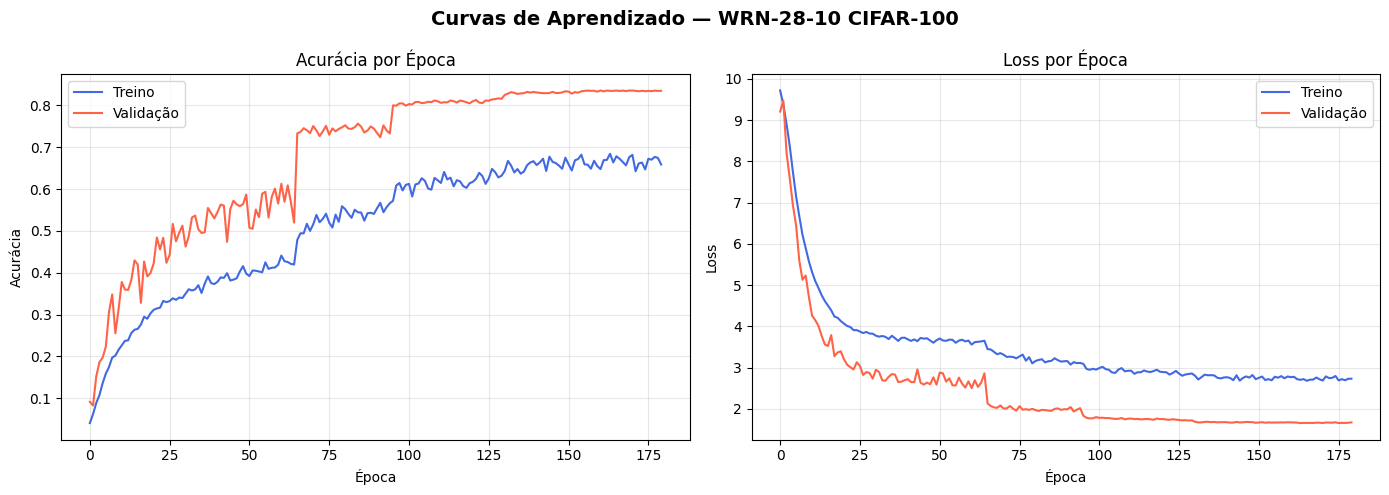

In [12]:
# ── 1. Curvas de Aprendizado ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizado — WRN-28-10 CIFAR-100', fontsize=14, fontweight='bold')

# Acurácia
axes[0].plot(history.history['accuracy'],     label='Treino',    color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Validação', color='tomato')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Treino',    color='royalblue')
axes[1].plot(history.history['val_loss'], label='Validação', color='tomato')
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(run_dir, 'curvas_aprendizado.png'), dpi=150, bbox_inches='tight')
plt.show()

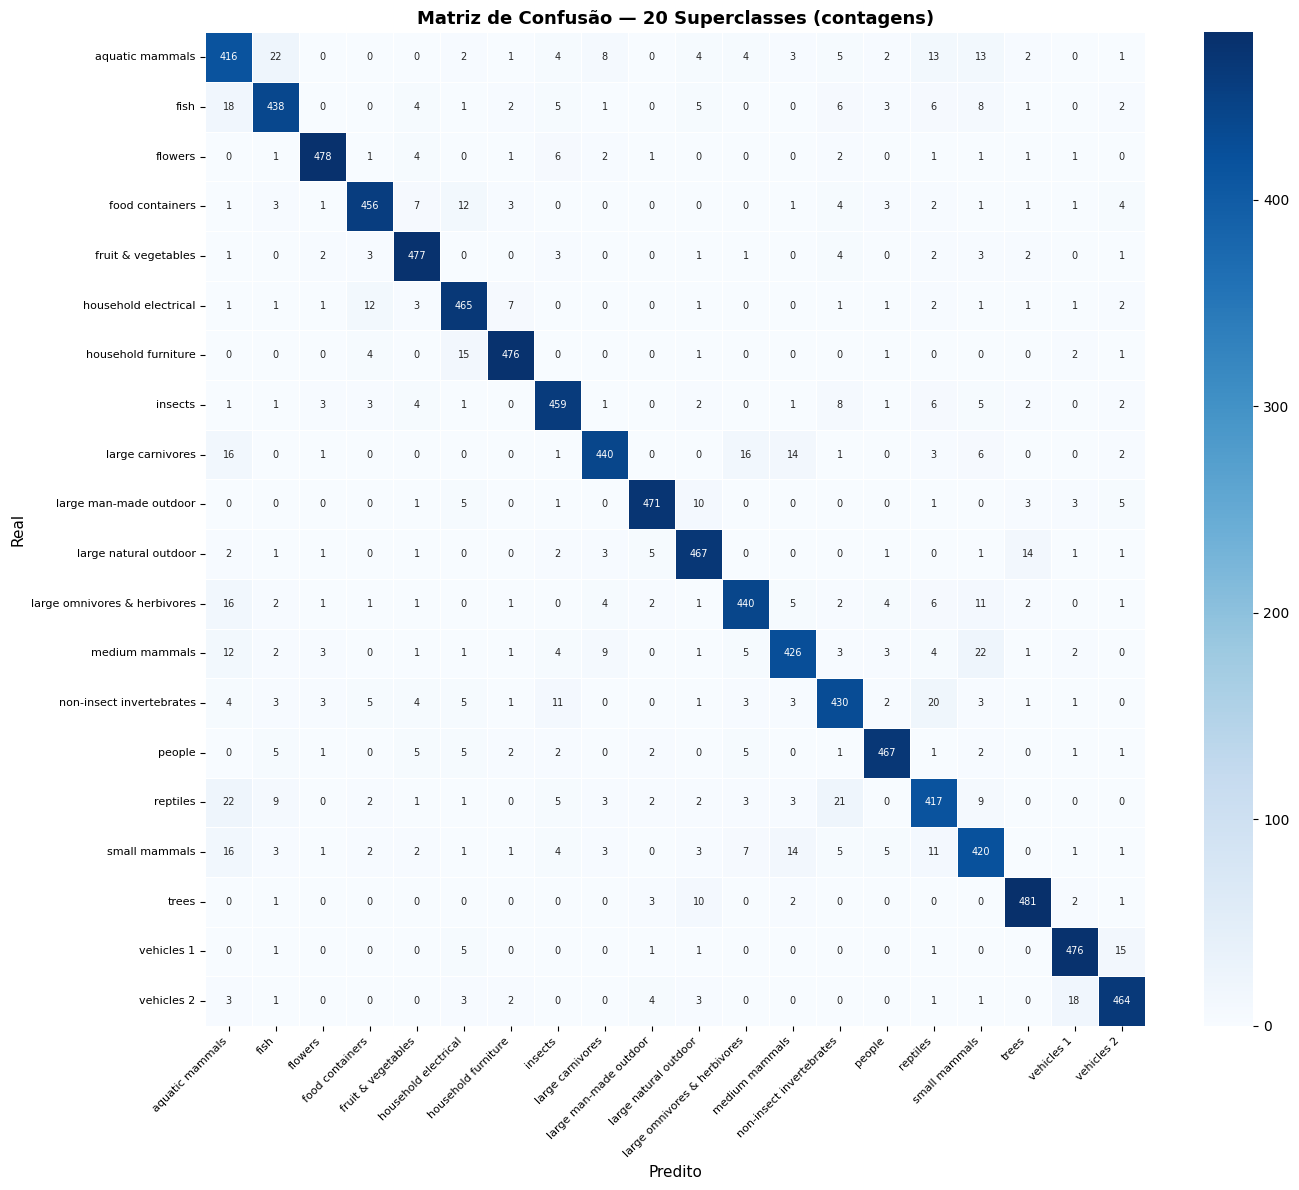

In [13]:
# ── 2. Matriz de Confusão (20 superclasses para ficar legível) ───────────────
# CIFAR-100 tem 100 classes — matriz 100x100 fica ilegível
# Usamos as 20 superclasses para visualização
superclasses = [
    'aquatic mammals', 'fish', 'flowers', 'food containers', 'fruit & vegetables',
    'household electrical', 'household furniture', 'insects', 'large carnivores',
    'large man-made outdoor', 'large natural outdoor', 'large omnivores & herbivores',
    'medium mammals', 'non-insect invertebrates', 'people', 'reptiles',
    'small mammals', 'trees', 'vehicles 1', 'vehicles 2'
]

# Mapeamento fine → coarse (oficial do CIFAR-100)
fine_to_coarse = [
    4, 1, 14, 8, 0, 6, 7, 7, 18, 3, 3, 14, 9, 18, 7, 11, 3, 9, 7, 11,
    6, 11, 5, 10, 7, 6, 13, 15, 3, 15, 0, 11, 1, 10, 12, 14, 16, 9, 11, 5,
    5, 19, 8, 8, 15, 13, 14, 17, 18, 10, 16, 4, 17, 4, 2, 0, 17, 4, 18, 17,
    10, 3, 2, 12, 12, 16, 12, 1, 9, 19, 2, 10, 0, 1, 16, 12, 9, 13, 15, 13,
    16, 19, 2, 4, 6, 19, 5, 5, 8, 19, 18, 1, 2, 15, 6, 0, 17, 8, 14, 13
]

y_true_coarse = np.array([fine_to_coarse[i] for i in y_true])
y_pred_coarse = np.array([fine_to_coarse[i] for i in y_pred])

cm = confusion_matrix(y_true_coarse, y_pred_coarse)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=superclasses, yticklabels=superclasses,
            ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Matriz de Confusão — 20 Superclasses (contagens)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predito', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(run_dir, 'matriz_confusao.png'), dpi=150, bbox_inches='tight')
plt.show()

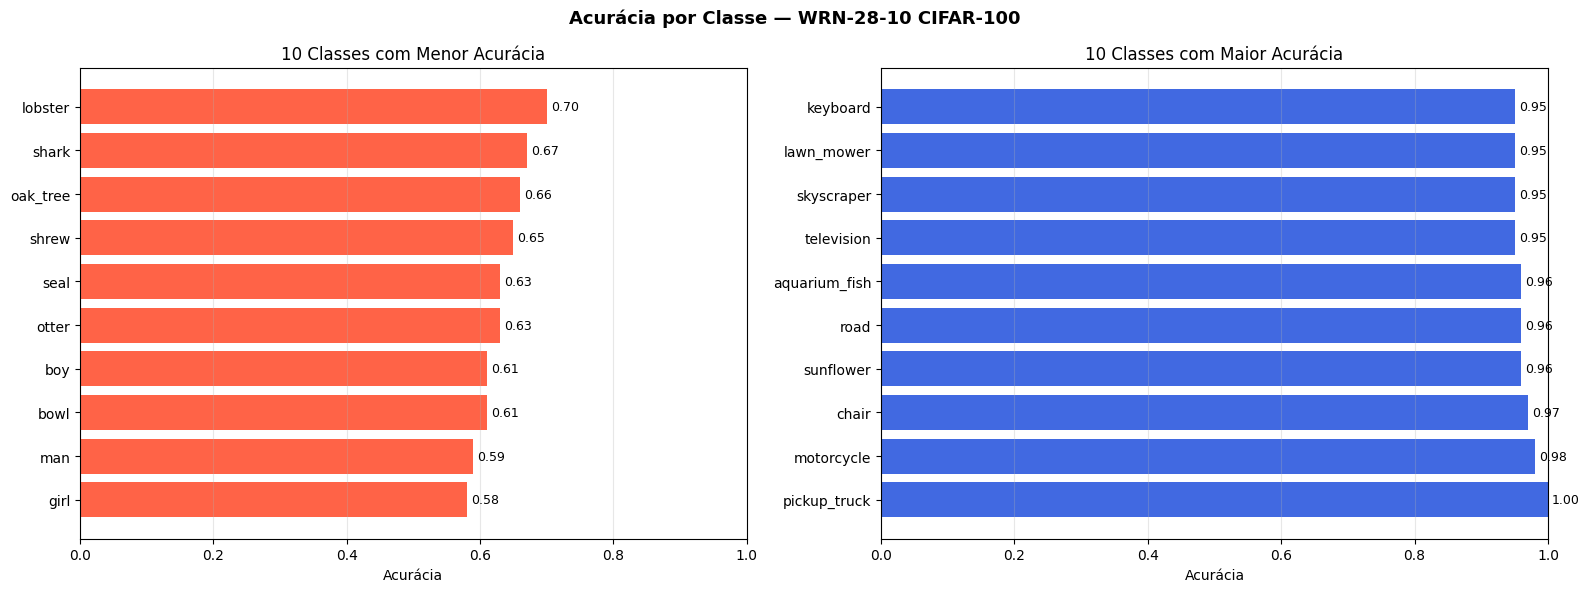

In [14]:
# ── 3. Top-10 classes com maior e menor acurácia ─────────────────────────────
acuracia_por_classe = []
for i in range(100):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        acuracia_por_classe.append((nomes_classes[i], acc))

acuracia_por_classe.sort(key=lambda x: x[1])

piores  = acuracia_por_classe[:10]
melhores = acuracia_por_classe[-10:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Acurácia por Classe — WRN-28-10 CIFAR-100', fontsize=13, fontweight='bold')

# Piores
nomes_p, vals_p = zip(*piores)
bars = axes[0].barh(nomes_p, vals_p, color='tomato')
axes[0].set_title('10 Classes com Menor Acurácia')
axes[0].set_xlabel('Acurácia')
axes[0].set_xlim(0, 1)
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
axes[0].grid(True, axis='x', alpha=0.3)

# Melhores
nomes_m, vals_m = zip(*melhores)
bars = axes[1].barh(nomes_m, vals_m, color='royalblue')
axes[1].set_title('10 Classes com Maior Acurácia')
axes[1].set_xlabel('Acurácia')
axes[1].set_xlim(0, 1)
axes[1].bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(run_dir, 'acuracia_por_classe.png'), dpi=150, bbox_inches='tight')
plt.show()

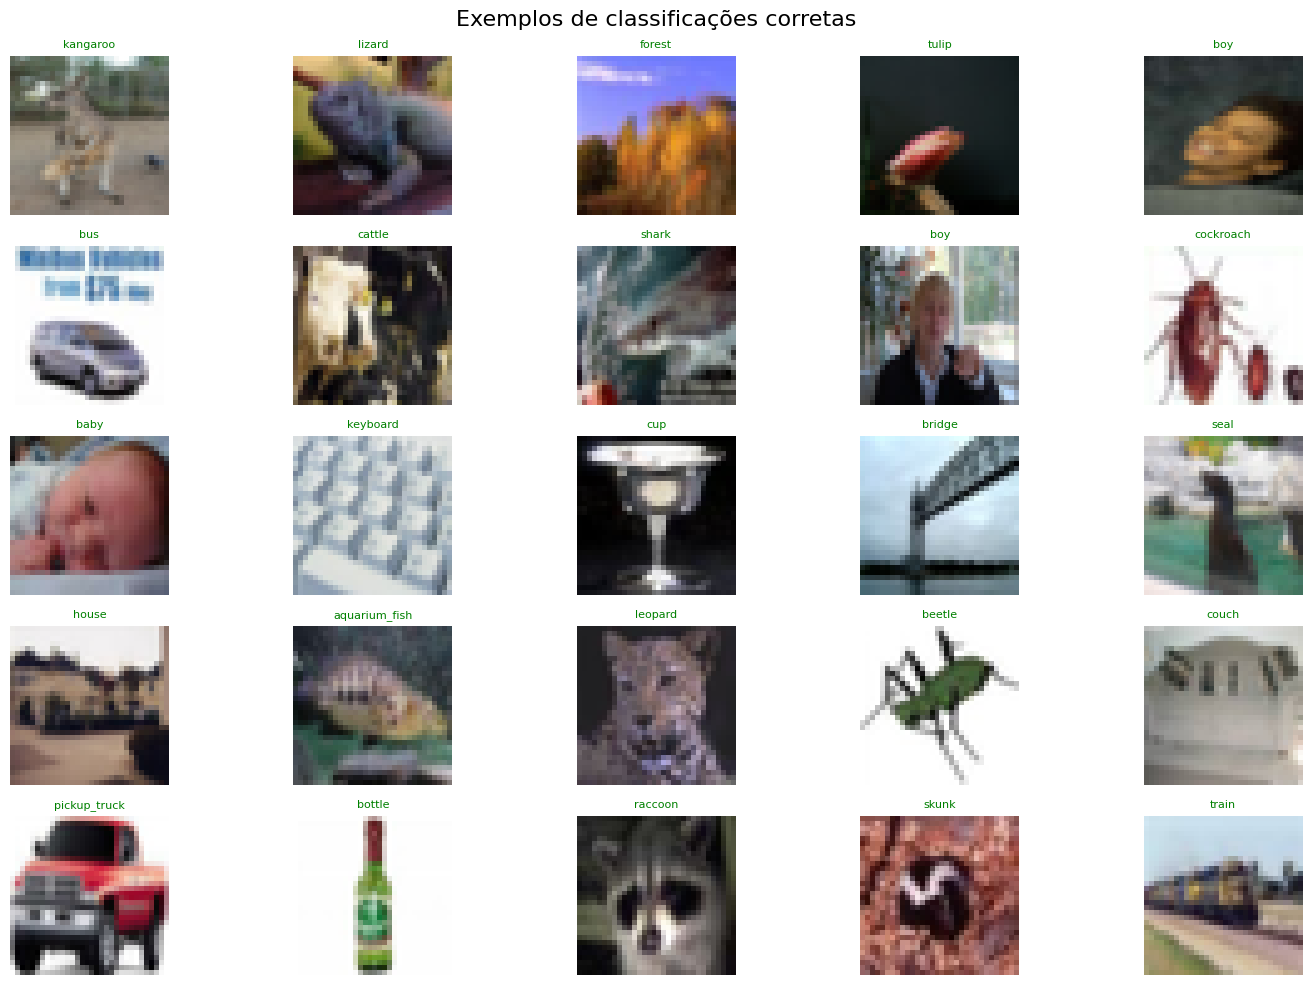

In [15]:
correct = np.where(y_pred == y_true)[0]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(np.random.choice(correct, 25, replace=False)):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_teste[idx])
    plt.axis("off")
    plt.title(nomes_classes[y_pred[idx]], fontsize=8, color='green')

plt.suptitle("Exemplos de classificações corretas", fontsize=16)
plt.tight_layout()
plt.show()

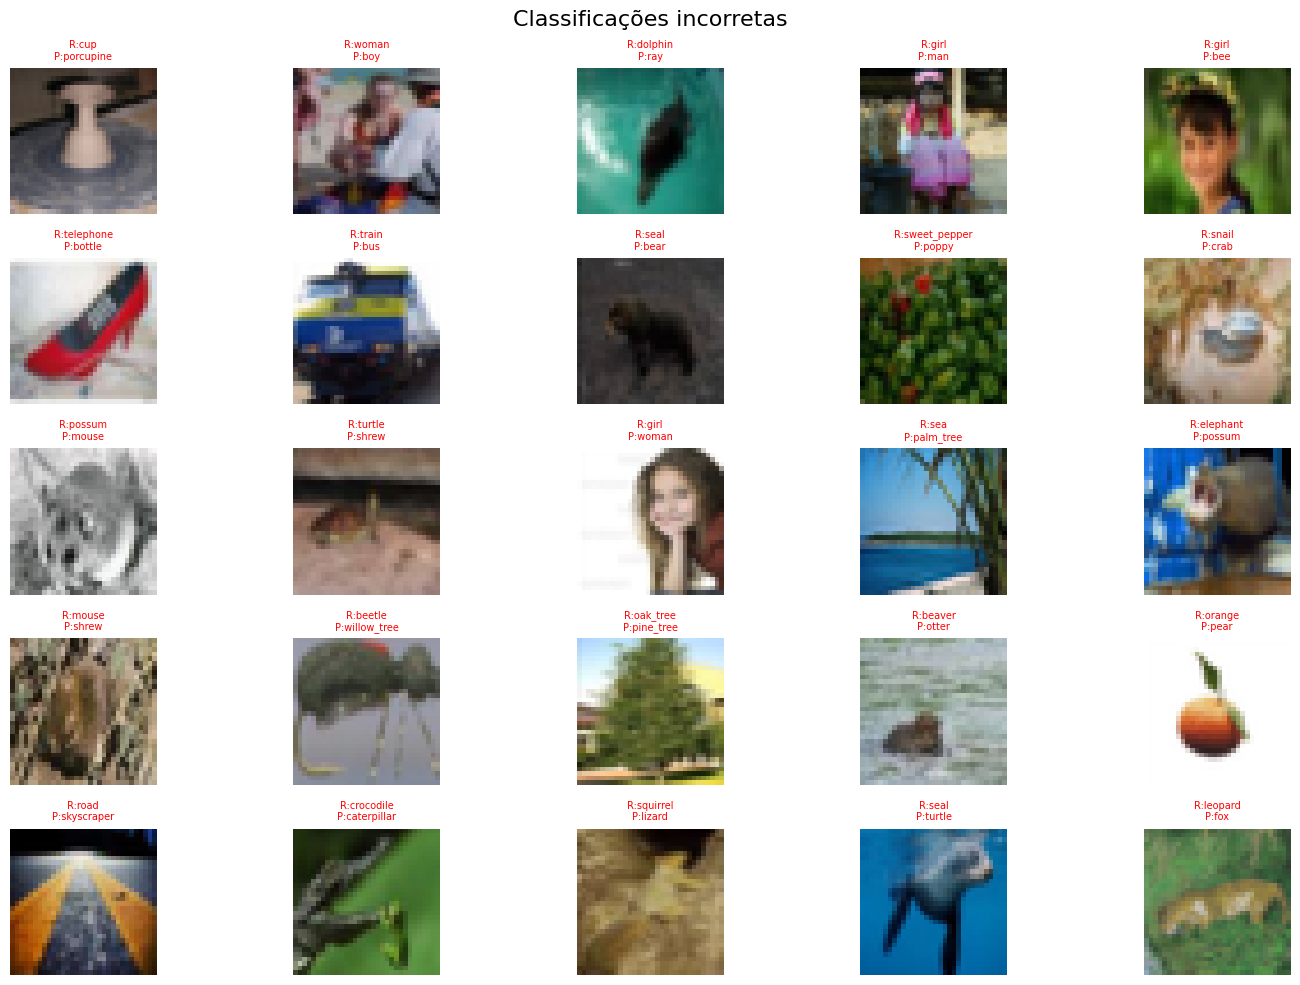

In [16]:
wrong = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(np.random.choice(wrong, 25, replace=False)):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_teste[idx])
    plt.axis("off")
    plt.title(
        f"R:{nomes_classes[y_true[idx]]}\nP:{nomes_classes[y_pred[idx]]}",
        fontsize=7,
        color="red"
    )

plt.suptitle("Classificações incorretas", fontsize=16)
plt.tight_layout()
plt.show()

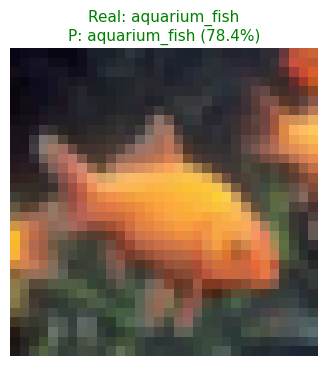

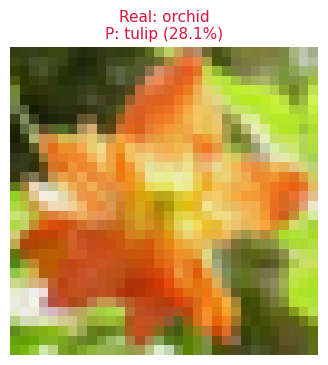

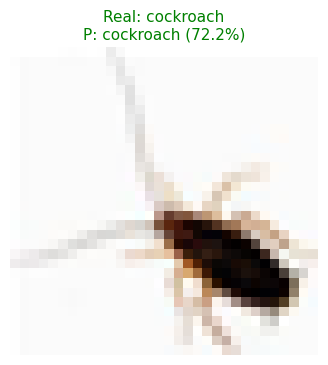

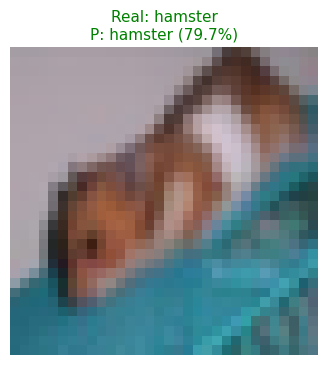

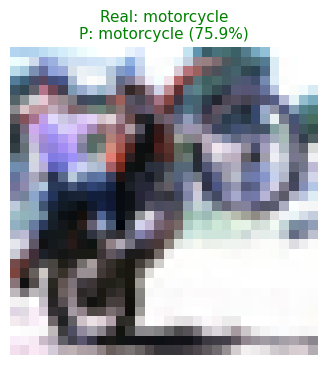

In [17]:
indices = np.random.choice(len(X_teste), 5, replace=False)

for idx in indices:
    plt.figure(figsize=(4, 4))
    plt.imshow(X_teste[idx])
    plt.axis("off")

    conf = np.max(y_pred_probs[idx])
    cor = "green" if y_pred[idx] == y_true[idx] else "crimson"
    plt.title(
        f"Real: {nomes_classes[y_true[idx]]}\n"
        f"P: {nomes_classes[y_pred[idx]]} ({conf * 100:.1f}%)",
        fontsize=11,
        color=cor
    )
    plt.show()

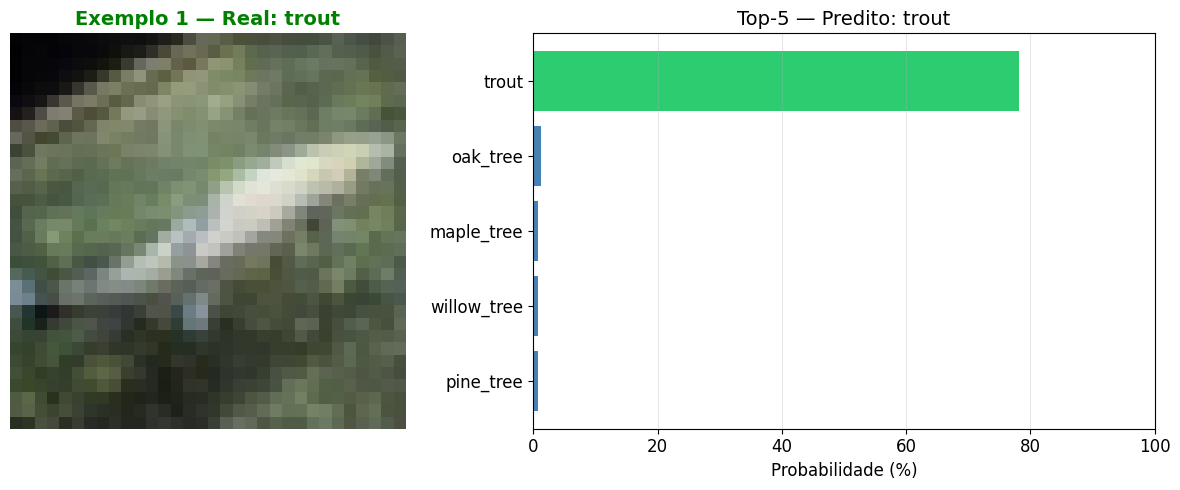

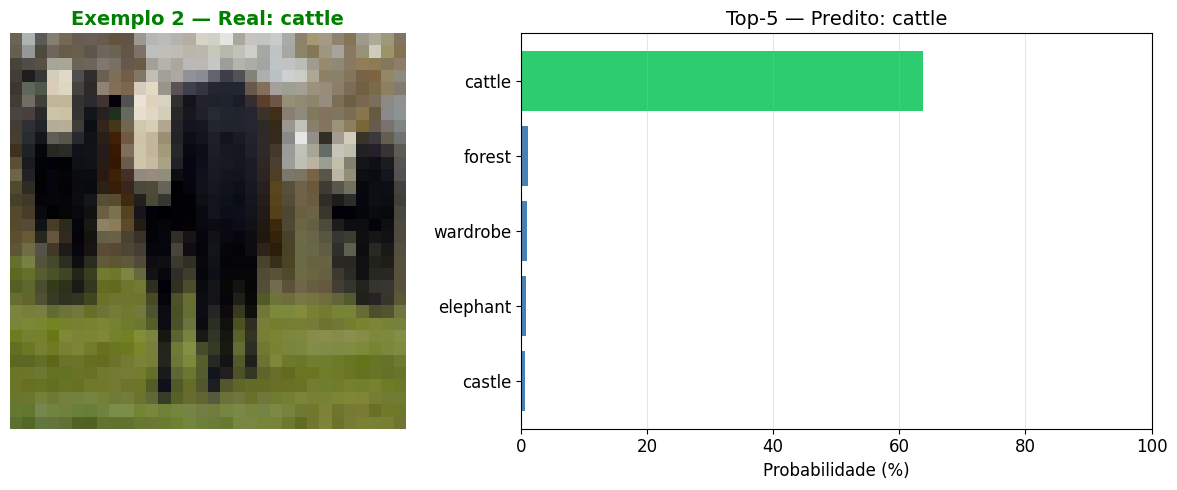

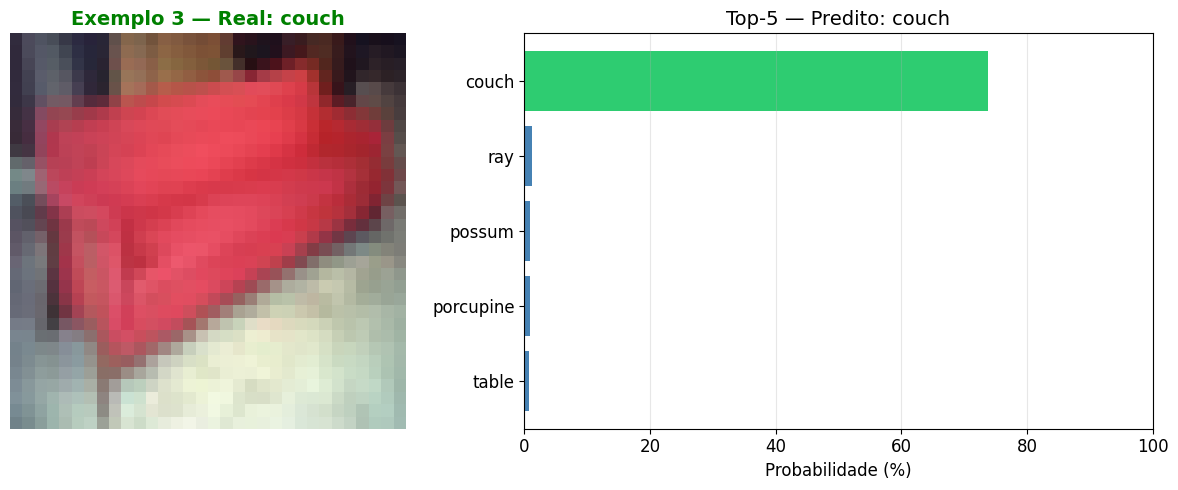

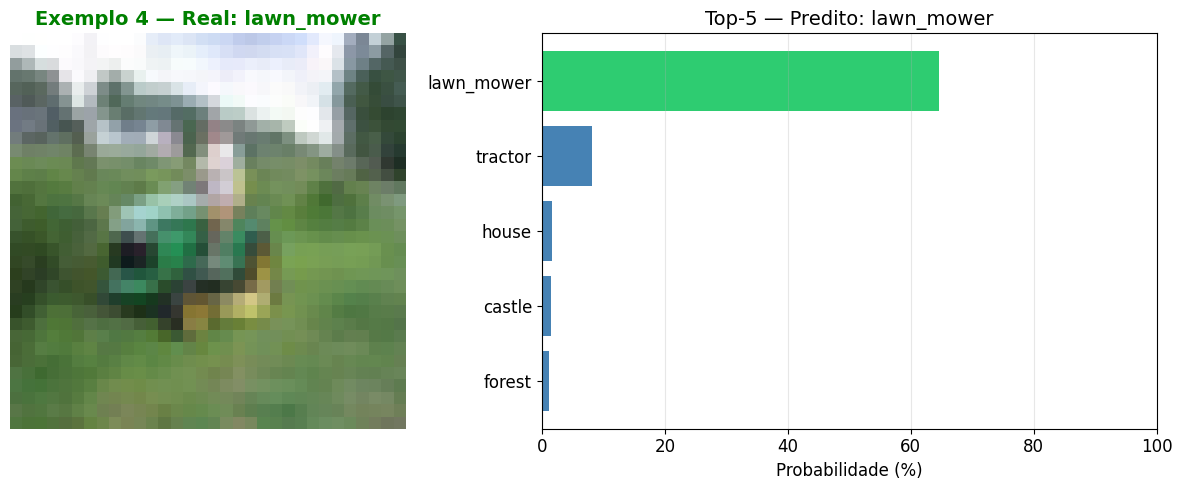

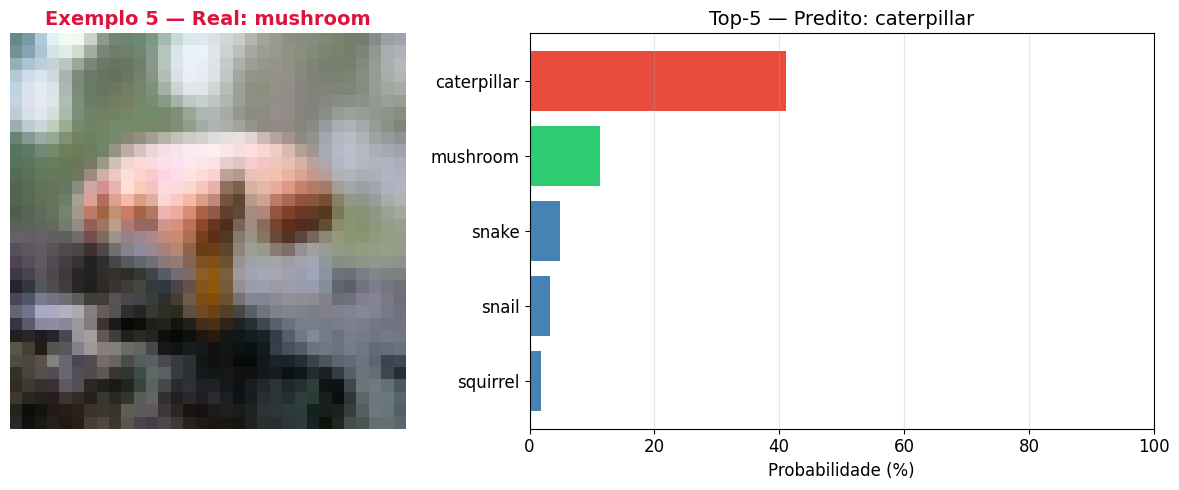

In [18]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(X_teste), 5, replace=False)

for n, idx in enumerate(indices, start=1):
    fig, (ax_img, ax_bar) = plt.subplots(
        1, 2, figsize=(12, 5),
        gridspec_kw={"width_ratios": [1, 1.5]}
    )

    ax_img.imshow(X_teste[idx])
    ax_img.axis("off")

    acertou = y_pred[idx] == y_true[idx]
    cor = "green" if acertou else "crimson"
    ax_img.set_title(
        f"Exemplo {n} — Real: {nomes_classes[y_true[idx]]}",
        fontsize=14,
        fontweight="bold",
        color=cor
    )

    top5 = np.argsort(y_pred_probs[idx])[-5:][::-1]
    probs = y_pred_probs[idx][top5] * 100
    labels = [nomes_classes[c] for c in top5]

    cores = [
        "#2ecc71" if c == y_true[idx]
        else "#e74c3c" if c == y_pred[idx]
        else "steelblue"
        for c in top5
    ]

    ax_bar.barh(labels[::-1], probs[::-1], color=cores[::-1])
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Probabilidade (%)", fontsize=12)
    ax_bar.set_title(
        f"Top-5 — Predito: {nomes_classes[y_pred[idx]]}",
        fontsize=14
    )
    ax_bar.tick_params(labelsize=12)
    ax_bar.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [19]:
print("=" * 70)
print("RESULTADOS FINAIS")
print("=" * 70)

print(f"Arquitetura      : WRN-{CONFIG['depth']}-{CONFIG['width']}")
print(f"Dataset          : CIFAR-100")
print(f"Épocas           : {CONFIG['epochs']}")
print(f"Optimizer        : SGD + Nesterov")
print(f"Scheduler        : Step decay (warmup 5 + decays em 65/95/130/155)")
print(f"EMA              : Não")
print(f"Label Smoothing  : {CONFIG['label_smoothing']}")
print("=" * 70)

RESULTADOS FINAIS
Arquitetura      : WRN-34-10
Dataset          : CIFAR-100
Épocas           : 180
Optimizer        : SGD + Nesterov
Scheduler        : Step decay (warmup 5 + decays em 65/95/130/155)
EMA              : Não
Label Smoothing  : 0.1
